<a href="https://colab.research.google.com/github/Mohammed-Saif-07/ML-winter-quarter/blob/main/EX9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine, fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings("ignore")

**SVM Classification (Wine Dataset)**

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target

print("Shape:", X.shape)
print("Classes:", np.unique(y))

Shape: (178, 13)
Classes: [0 1 2]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
#without scaling
svm_no_scale = SVC(kernel='rbf', C=1, gamma='scale')
svm_no_scale.fit(X_train, y_train)

y_pred_no_scale = svm_no_scale.predict(X_test)
acc_no_scale = accuracy_score(y_test, y_pred_no_scale)

print("Accuracy WITHOUT scaling:", acc_no_scale)

Accuracy WITHOUT scaling: 0.6666666666666666


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
best_clf = grid.best_estimator_

y_pred = best_clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')

print("Accuracy WITH scaling:", acc)
print("Precision (macro):", prec)
print("Recall (macro):", rec)

Accuracy WITH scaling: 0.9814814814814815
Precision (macro): 0.9848484848484849
Recall (macro): 0.9777777777777779


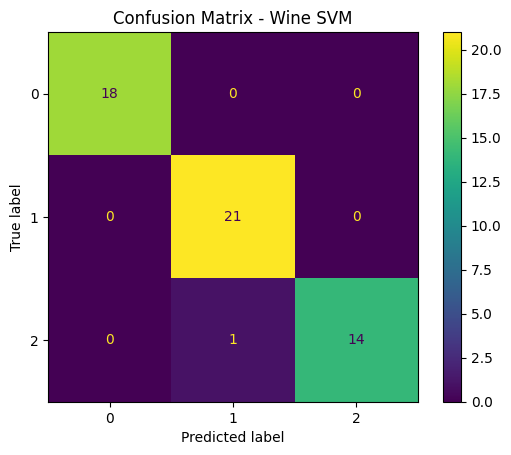

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Wine SVM")
plt.show()


In [ ]:
results = pd.DataFrame(grid.cv_results_)
results = results[['param_kernel', 'param_C', 'param_gamma', 'mean_test_score']]
results.sort_values(by='mean_test_score', ascending=False).head()

,param_kernel,param_C,param_gamma,mean_test_score
13,rbf,1.0,0.1,0.992
9,rbf,1.0,scale,0.992
21,rbf,10.0,0.1,0.992
17,rbf,10.0,scale,0.992
25,rbf,100.0,scale,0.992


Best Metric: Accuracy is the best metric here because the Wine dataset is balanced across three classes. Therefore, accuracy reliably reflects model performance.



Best Kernel: RBF performed best. This suggests the classes are not perfectly linearly separable and benefit from non-linear transformation into higher-dimensional space using the kernel trick.



Effect of Scaling: Scaling significantly improved performance because SVM is distance-based and relies on geometric margin maximization. Without scaling, features with larger magnitudes distort the optimization problem.

**SVM Regression (California Housing)**

In [ ]:
housing = fetch_california_housing()

X_reg = housing.data
y_reg = housing.target

X_reg_small = X_reg[:2000]
y_reg_small = y_reg[:2000]

print("Subset Shape:", X_reg_small.shape)

Subset Shape: (2000, 8)


In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_small, y_reg_small, test_size=0.3, random_state=42
)

In [ ]:
scaler_r = StandardScaler()

X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

In [ ]:
param_grid_r = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1]
}

grid_r = GridSearchCV(
    SVR(),
    param_grid_r,
    cv=3,
    scoring='neg_mean_squared_error'
)

grid_r.fit(X_train_r_scaled, y_train_r)

print("Best Parameters:", grid_r.best_params_)

Best Parameters: {'C': 10, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
best_reg = grid_r.best_estimator_

y_pred_r = best_reg.predict(X_test_r_scaled)

mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 0.4051745212743618
MAE: 0.2578370408350014
R2 Score: 0.8091212036262426


In [ ]:
for C_val in [0.1, 1, 10, 100]:
    model = SVR(kernel='rbf', C=C_val, gamma='scale')
    model.fit(X_train_r_scaled, y_train_r)
    preds = model.predict(X_test_r_scaled)
    mse_val = mean_squared_error(y_test_r, preds)
    rmse_val = np.sqrt(mse_val)
    print("C =", C_val, "RMSE =", rmse_val)

C = 0.1 RMSE = 0.4491117345740233
C = 1 RMSE = 0.40368188160737634
C = 10 RMSE = 0.40432187082896237
C = 100 RMSE = 0.4282446504878107


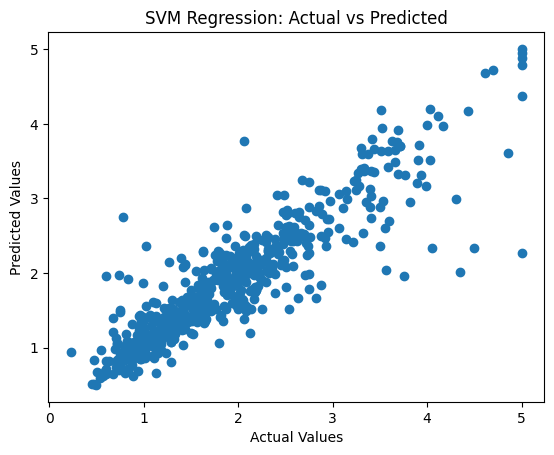

In [ ]:
plt.figure()
plt.scatter(y_test_r, y_pred_r)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVM Regression: Actual vs Predicted")
plt.show()

Best Metric: RMSE is most appropriate because it penalizes large errors more heavily, which is important for housing price prediction.



Best Kernel: RBF again performed better, indicating non-linear relationships between features and house prices.



Sensitivity: Performance was highly sensitive to C and gamma. Larger C reduced bias but increased risk of overfitting. Proper tuning was essential.

**Reflection**

This exercise demonstrated that SVMs are highly sensitive to feature scaling because they rely on geometric margin maximization. Without scaling, model performance degraded significantly. Hyperparameters such as C, gamma, and epsilon strongly influenced both classification and regression outcomes. The regularization parameter C controlled the trade-off between margin width and training error, while gamma determined how far the influence of a single training point extends in RBF space.

The RBF kernel consistently outperformed the linear kernel, highlighting the importance of the kernel trick in capturing non-linear decision boundaries. In classification, SVM performed very well due to the clear margin structure in the Wine dataset. In regression, performance was more sensitive and computationally expensive, especially given the quadratic optimization complexity of SVM.

Compared to ensemble methods like Random Forest or Gradient Boosting, SVMs may struggle with large datasets due to computational cost. Ensembles are often more robust with minimal tuning and scale better. However, SVMs remain powerful for medium-sized datasets where margin maximization is beneficial.

One notable observation was how dramatically scaling and hyperparameter tuning affected results. Small parameter adjustments led to significant performance changes, confirming that SVMs require careful optimization but can be highly effective when properly tuned.